# XGBoost BPM Prediction Pipeline

This notebook contains only the preprocessing/feature engineering and an XGBoost training pipeline (with optional random search and seed ensembling) to generate a Kaggle submission.


In [10]:
# Imports and paths
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

cur_dir = os.getcwd()
DATA_DIR = Path(cur_dir) / "data"
train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

print("Train path exists:", train_path.exists())
print("Test path exists:", test_path.exists())


Train path exists: True
Test path exists: True


In [11]:
# Load data
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
TARGET = "BeatsPerMinute"
features_all = [c for c in train.columns if c not in ["id", TARGET]]
print({"train": train.shape, "test": test.shape})


{'train': (524164, 11), 'test': (174722, 10)}


In [12]:
# Quick dataset exploration
from IPython.display import display

print({"train_shape": train.shape, "test_shape": test.shape})
print("\nColumns:")
print(train.columns.tolist())

print("\nHead (train):")
display(train.head())

print("\nDescribe (numeric, train):")
display(train.describe())

print("\nMissing values (train):")
display(train.isna().sum().sort_values(ascending=False))

print("\nMissing values (test):")
display(test.isna().sum().sort_values(ascending=False))


{'train_shape': (524164, 11), 'test_shape': (174722, 10)}

Columns:
['id', 'RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality', 'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore', 'TrackDurationMs', 'Energy', 'BeatsPerMinute']

Head (train):


,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511



Describe (numeric, train):


,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,262081.500000,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,151313.257587,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.000000,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,131040.750000,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,262081.500000,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,393122.250000,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,524163.000000,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000



Missing values (train):


id                           0
RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
BeatsPerMinute               0
dtype: int64


Missing values (test):


id                           0
RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
dtype: int64

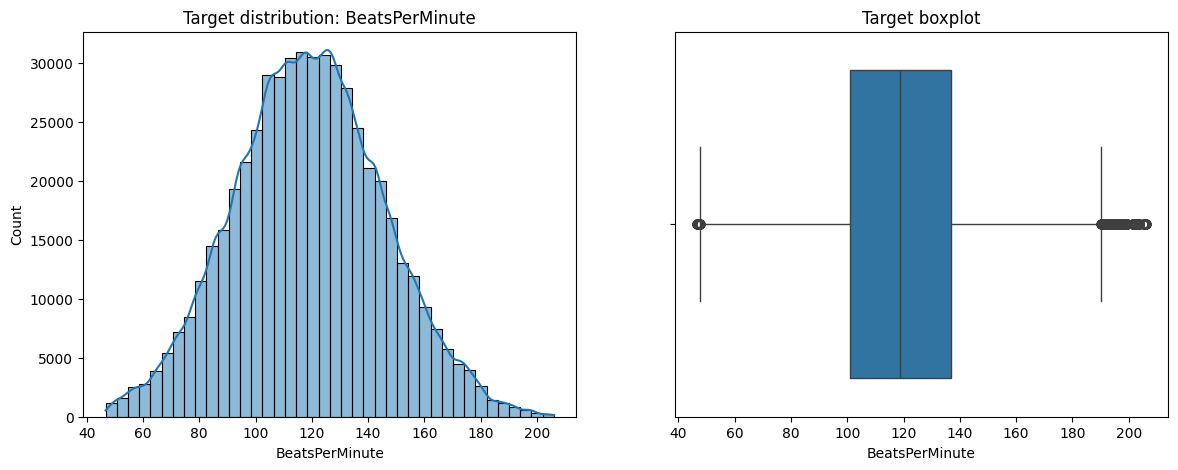

Top correlations with target:


MoodScore                    0.007059
TrackDurationMs              0.006637
RhythmScore                  0.005440
VocalContent                 0.004876
LivePerformanceLikelihood    0.003471
InstrumentalScore            0.001900
id                          -0.000355
AcousticQuality             -0.000820
AudioLoudness               -0.003327
Energy                      -0.004375
Name: BeatsPerMinute, dtype: float64

In [13]:
# Target distribution and correlations
import seaborn as sns
import matplotlib.pyplot as plt

if TARGET in train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(train[TARGET].dropna(), kde=True, bins=40, ax=axes[0])
    axes[0].set_title("Target distribution: BeatsPerMinute")
    sns.boxplot(x=train[TARGET], ax=axes[1])
    axes[1].set_title("Target boxplot")
    plt.show()

    numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    corr = train[numeric_cols].corr(numeric_only=True)
    top = corr[TARGET].drop(labels=[TARGET]).sort_values(ascending=False).head(15)
    print("Top correlations with target:")
    display(top)
else:
    print("Target column not found in train.")


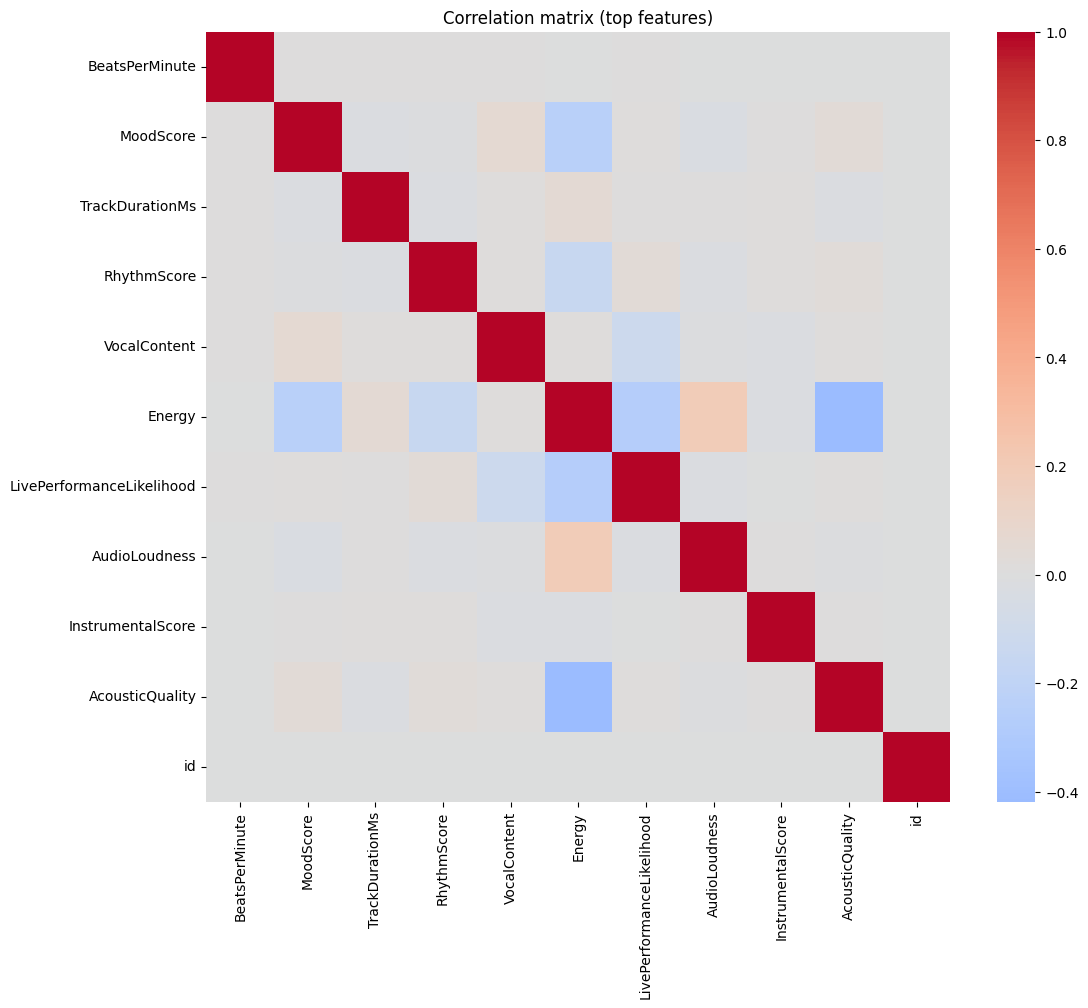

In [14]:
# Correlation matrix heatmap (top features)
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr(numeric_only=True)

# Select top features by absolute correlation with target
if TARGET in corr.columns:
    top_feats = corr[TARGET].abs().sort_values(ascending=False).head(20).index.tolist()
    cm = corr.loc[top_feats, top_feats]
else:
    # Fallback: overall top-20 by mean absolute corr
    mac = corr.abs().mean().sort_values(ascending=False).head(20).index.tolist()
    cm = corr.loc[mac, mac]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation matrix (top features)")
plt.show()


In [21]:
# Printable correlations (CSV text you can copy/paste)
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr(numeric_only=True)

if TARGET in corr.columns:
    top_series = corr[TARGET].drop(labels=[TARGET]).sort_values(ascending=False).head(20)
    top_feats = [TARGET] + top_series.index.tolist()
    cm = corr.loc[top_feats, top_feats].round(6)

    print("Top 20 correlations with target (CSV):")
    print(top_series.round(6).to_csv(header=[TARGET]))

    print("Correlation matrix for [target + top 20] (CSV):")
    print(cm.to_csv())
else:
    print("Target column not found; printing overall top-20 mean-abs-corr matrix.")
    mac = corr.abs().mean().sort_values(ascending=False).head(20).index.tolist()
    cm = corr.loc[mac, mac].round(6)
    print(cm.to_csv())


Top 20 correlations with target (CSV):
,BeatsPerMinute
MoodScore,0.007059
TrackDurationMs,0.006637
RhythmScore,0.00544
VocalContent,0.004876
LivePerformanceLikelihood,0.003471
InstrumentalScore,0.0019
id,-0.000355
AcousticQuality,-0.00082
AudioLoudness,-0.003327
Energy,-0.004375

Correlation matrix for [target + top 20] (CSV):
,BeatsPerMinute,MoodScore,TrackDurationMs,RhythmScore,VocalContent,LivePerformanceLikelihood,InstrumentalScore,id,AcousticQuality,AudioLoudness,Energy
BeatsPerMinute,1.0,0.007059,0.006637,0.00544,0.004876,0.003471,0.0019,-0.000355,-0.00082,-0.003327,-0.004375
MoodScore,0.007059,1.0,-0.014803,-0.008946,0.058675,0.015461,0.004738,0.001597,0.037047,-0.027305,-0.241713
TrackDurationMs,0.006637,-0.014803,1.0,-0.01764,0.018179,0.005179,0.00934,-0.001508,-0.022524,0.00451,0.048597
RhythmScore,0.00544,-0.008946,-0.01764,1.0,0.008737,0.031535,0.010992,0.000196,0.028203,-0.017385,-0.14735
VocalContent,0.004876,0.058675,0.018179,0.008737,1.0,-0.120294,-0.017739,-0.000863,0.

In [22]:
# Feature engineering helpers
from dataclasses import dataclass

@dataclass
class FEStats:
    means: pd.Series
    stds: pd.Series


def compute_stats(df: pd.DataFrame, exclude_cols: list[str]) -> FEStats:
    num_cols = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]
    means = df[num_cols].mean()
    stds = df[num_cols].std(ddof=1).replace(0, np.nan)
    return FEStats(means=means, stds=stds)


def feature_engineering(df: pd.DataFrame, stats: FEStats, is_train: bool, target_col: str = "BeatsPerMinute") -> pd.DataFrame:
    out = df.copy()
    exclude = {"id", target_col}
    numeric_cols = [c for c in out.columns if c not in exclude and pd.api.types.is_numeric_dtype(out[c])]

    if "TrackDurationMs" in out.columns:
        out["TrackDurationSec"] = out["TrackDurationMs"] / 1000.0
        out["log_TrackDurationMs"] = np.log1p(out["TrackDurationMs"].clip(lower=0))

    bounded_cols = [c for c in numeric_cols if (out[c].min() >= 0) and (out[c].max() <= 1)]
    for c in bounded_cols:
        eps = 1e-6
        out[f"logit_{c}"] = np.log((out[c].clip(eps, 1-eps)) / (1 - out[c].clip(eps, 1-eps)))

    if set(["Energy", "AudioLoudness"]).issubset(out.columns):
        out["Energy_x_Loudness"] = out["Energy"] * (-out["AudioLoudness"]) 
        out["Energy_div_LoudnessMag"] = out["Energy"] / (1e-6 + (-out["AudioLoudness"]).abs())

    if set(["RhythmScore", "Energy"]).issubset(out.columns):
        out["Rhythm_x_Energy"] = out["RhythmScore"] * out["Energy"]

    if set(["VocalContent", "InstrumentalScore"]).issubset(out.columns):
        out["Vocal_minus_Instrumental"] = out["VocalContent"] - out["InstrumentalScore"]
        out["Vocal_div_Instrumental"] = out["VocalContent"] / (1e-6 + out["InstrumentalScore"]) 

    if "AcousticQuality" in out.columns:
        for partner in ["Energy", "RhythmScore", "VocalContent", "InstrumentalScore", "MoodScore"]:
            if partner in out.columns:
                out[f"AcousticQuality_x_{partner}"] = out["AcousticQuality"] * out[partner]

    if "LivePerformanceLikelihood" in out.columns:
        for partner in ["Energy", "RhythmScore", "MoodScore"]:
            if partner in out.columns:
                out[f"LivePerf_x_{partner}"] = out["LivePerformanceLikelihood"] * out[partner]

    for c in numeric_cols:
        if c in stats.means.index:
            mean_c = stats.means[c]
            std_c = stats.stds[c]
            if pd.notna(std_c) and std_c > 0:
                out[f"z_{c}"] = (out[c] - mean_c) / std_c

    return out


In [23]:
# Enhanced feature engineering (toggle via USE_ENHANCED_FE)
USE_ENHANCED_FE = True

from scipy.stats import rankdata

def feature_engineering_enhanced(df: pd.DataFrame, stats: FEStats, is_train: bool, target_col: str = "BeatsPerMinute") -> pd.DataFrame:
    out = feature_engineering(df, stats, is_train=is_train, target_col=target_col).copy()

    # Helpers
    def loudness_mag(s: pd.Series) -> pd.Series:
        return (-s).abs()

    # 1) MoodScore nonlinearities and interactions
    if "MoodScore" in out.columns:
        out["sq_MoodScore"] = out["MoodScore"] ** 2
        out["sqrt_MoodScore"] = np.sqrt(out["MoodScore"].clip(lower=0))
        out["rank_MoodScore"] = rankdata(out["MoodScore"]) / len(out)
        for p in ["RhythmScore", "TrackDurationMs", "LivePerformanceLikelihood", "Energy"]:
            if p in out.columns:
                out[f"Mood_x_{p}"] = out["MoodScore"] * out[p]

    # 2) Energy-Loudness block
    if "Energy" in out.columns:
        out["sq_Energy"] = out["Energy"] ** 2
        if "AudioLoudness" in out.columns:
            lm = loudness_mag(out["AudioLoudness"])
            out["sq_LoudnessMag"] = lm ** 2
            out["Energy_to_LoudnessMag_ratio"] = out["Energy"] / (1e-6 + lm)
            out["LoudnessMag"] = lm
        for p in ["RhythmScore", "AcousticQuality"]:
            if p in out.columns:
                out[f"Energy_x_{p}"] = out["Energy"] * out[p]

    # 3) Rhythm/LivePerformance
    if "RhythmScore" in out.columns:
        out["sq_RhythmScore"] = out["RhythmScore"] ** 2
        if "LivePerformanceLikelihood" in out.columns:
            out["Rhythm_x_LivePerf"] = out["RhythmScore"] * out["LivePerformanceLikelihood"]
        if "AcousticQuality" in out.columns:
            out["Rhythm_x_AcousticQuality"] = out["RhythmScore"] * out["AcousticQuality"]

    # 4) Duration block
    if "TrackDurationMs" in out.columns:
        out["sqrt_TrackDurationMs"] = np.sqrt(out["TrackDurationMs"].clip(lower=0))
        out["rank_TrackDurationMs"] = rankdata(out["TrackDurationMs"]) / len(out)
        if "RhythmScore" in out.columns:
            out["Duration_x_Rhythm"] = out["TrackDurationMs"] * out["RhythmScore"]
        if "MoodScore" in out.columns:
            out["Duration_x_Mood"] = out["TrackDurationMs"] * out["MoodScore"]

    # 5) AcousticQuality hub
    if "AcousticQuality" in out.columns:
        if "AudioLoudness" in out.columns:
            out["AcousticQuality_x_LoudnessMag"] = out["AcousticQuality"] * loudness_mag(out["AudioLoudness"]) 

    # 6) Winsorize extremes for stability
    def winsorize(series: pd.Series, lower_q: float = 0.001, upper_q: float = 0.999) -> pd.Series:
        lo, hi = series.quantile(lower_q), series.quantile(upper_q)
        return series.clip(lo, hi)

    for col in [c for c in ["LoudnessMag", "TrackDurationMs"] if c in out.columns]:
        out[f"wins_{col}"] = winsorize(out[col])

    # Recreate Z-scores for newly created numeric features (optional lightweight)
    num_cols = [c for c in out.columns if c not in {"id", target_col} and pd.api.types.is_numeric_dtype(out[c])]
    means = out[num_cols].mean()
    stds = out[num_cols].std(ddof=1).replace(0, np.nan)
    for c in num_cols:
        sd = stds[c]
        if pd.notna(sd) and sd > 0:
            out[f"z_{c}"] = (out[c] - means[c]) / sd

    return out


In [24]:
# Apply FE
EXCLUDE = ["id", TARGET]
stats = compute_stats(train, EXCLUDE)
train_fe = feature_engineering_enhanced(train, stats, is_train=True)
test_fe = feature_engineering_enhanced(test, stats, is_train=False)

features = [c for c in train_fe.columns if c not in ["id", TARGET]]
X = train_fe[features]
y = train_fe[TARGET]
X_test = test_fe[features]
print({"X": X.shape, "X_test": X_test.shape})


{'X': (524164, 117), 'X_test': (174722, 117)}


In [25]:
# Random Search for XGBoost hyperparameters
import random
from typing import Dict, Any
from sklearn.model_selection import StratifiedKFold


def sample_xgb_params() -> Dict[str, Any]:
    return {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'learning_rate': random.choice([0.03, 0.04, 0.05, 0.06, 0.07]),
        'max_depth': 0,  # use max_leaves
        'max_leaves': random.choice([64, 128, 192, 256, 384, 512]),
        'min_child_weight': random.uniform(1.0, 20.0),
        'subsample': random.uniform(0.6, 1.0),
        'colsample_bytree': random.uniform(0.6, 1.0),
        'reg_alpha': random.uniform(0.0, 1.0),
        'reg_lambda': random.uniform(0.0, 2.0),
        'tree_method': 'hist',
    }


def random_search_xgb(X: pd.DataFrame, y: pd.Series, bins: np.ndarray, n_trials: int = 25, n_splits: int = 5, base_seed: int = 220296) -> Dict[str, Any]:
    import xgboost as xgb
    best_rmse = float('inf')
    best_params = None
    for t in range(n_trials):
        params = sample_xgb_params()
        params['seed'] = base_seed + t
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=base_seed + t)
        oof = np.zeros(len(X))
        for trn_idx, val_idx in skf.split(X, bins):
            X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
            dtr = xgb.DMatrix(X_tr, label=y_tr)
            dvl = xgb.DMatrix(X_val, label=y_val)
            model = xgb.train(params, dtr, num_boost_round=20000,
                              evals=[(dtr,'train'), (dvl,'valid')],
                              early_stopping_rounds=200,
                              verbose_eval=False)
            oof[val_idx] = model.predict(dvl, iteration_range=(0, model.best_iteration + 1))
        rmse = np.sqrt(mean_squared_error(y, oof))
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params
    return best_params


In [27]:
# XGBoost CV + seed ensemble (optional random search)
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

# Use random search best params then seed ensemble
BEST = random_search_xgb(X, y, bins, n_trials=25, n_splits=5, base_seed=220296)
print({"best_random_params": BEST})

# Train seed ensemble with BEST params
SEEDS = [220296, 7, 19, 101, 1337]
ens_pred = np.zeros(len(X_test))
for s in SEEDS:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
    tmp_pred = np.zeros(len(X_test))
    for trn_idx, val_idx in skf.split(X, bins):
        X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
        dtr = xgb.DMatrix(X_tr, label=y_tr)
        dvl = xgb.DMatrix(X_val, label=y_val)
        dte = xgb.DMatrix(X_test)
        model = xgb.train(BEST | {'seed': s}, dtr, num_boost_round=20000,
                          evals=[(dtr,'train'), (dvl,'valid')],
                          early_stopping_rounds=200,
                          verbose_eval=False)
        tmp_pred += model.predict(dte, iteration_range=(0, model.best_iteration + 1)) / 5
    ens_pred += tmp_pred / len(SEEDS)

SUB_DIR = Path(cur_dir) / "submissions"
SUB_DIR.mkdir(parents=True, exist_ok=True)
sub_path = SUB_DIR / "submission_xgb_pipeline_random.csv"
pd.DataFrame({"id": test_fe["id"], "BeatsPerMinute": ens_pred}).to_csv(sub_path, index=False)
print(f"Wrote submission: {sub_path}")


{'best_random_params': {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'learning_rate': 0.04, 'max_depth': 0, 'max_leaves': 64, 'min_child_weight': 12.805005098888405, 'subsample': 0.7634813096920047, 'colsample_bytree': 0.8546839116100826, 'reg_alpha': 0.8342312142877023, 'reg_lambda': 0.05001227554393939, 'tree_method': 'hist', 'seed': 220303}}
Wrote submission: /Users/lukasweigand/Documents/Projekt Mios/Kaggle-bpm-prediction/submissions/submission_xgb_pipeline_random.csv
